# Notebook 04 — Model Training & Comparison

## Job Acceptance Prediction System



### Models
- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting
- Support Vector Machine (SVM)

### Evaluation
The models are compared using:
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Confusion Matrix
- ROC Curve


## 1. Import Libraries and Configure Paths

In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import sparse

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

PROJECT_ROOT = Path(os.getcwd()).resolve().parent
MODEL_DIR = PROJECT_ROOT / "models"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

if not (MODEL_DIR / "train_test_data.joblib").exists():
    PROJECT_ROOT = Path(os.getcwd()).resolve()
    MODEL_DIR = PROJECT_ROOT / "models"
    OUTPUT_DIR = PROJECT_ROOT / "outputs"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_TEST_PATH = MODEL_DIR / "train_test_data.joblib"
PREPROCESSOR_PATH = MODEL_DIR / "preprocessor.joblib"
FEATURE_NAMES_PATH = MODEL_DIR / "feature_names.joblib"

print("Project root:", PROJECT_ROOT)
print("Train/test artifact:", TRAIN_TEST_PATH)
print("Preprocessor:", PREPROCESSOR_PATH)

Project root: D:\job acceptance prediction system
Train/test artifact: D:\job acceptance prediction system\models\train_test_data.joblib
Preprocessor: D:\job acceptance prediction system\models\preprocessor.joblib


## 2. Load Notebook 03 Artifacts

In [2]:
if not TRAIN_TEST_PATH.exists():
    raise FileNotFoundError(
        "train_test_data.joblib was not found. "
        "Run Notebook 03 successfully first."
    )

if not PREPROCESSOR_PATH.exists():
    raise FileNotFoundError(
        "preprocessor.joblib was not found. "
        "Run Notebook 03 successfully first."
    )

data = joblib.load(TRAIN_TEST_PATH)
preprocessor = joblib.load(PREPROCESSOR_PATH)

X_train = data["X_train"]
X_test = data["X_test"]
y_train = np.asarray(data["y_train"])
y_test = np.asarray(data["y_test"])

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)
print("Preprocessor:", type(preprocessor))

X_train: (39888, 102)
X_test: (9972, 102)
y_train: (39888,)
y_test: (9972,)
Preprocessor: <class 'sklearn.compose._column_transformer.ColumnTransformer'>


## 3. Validate the Modeling Data

In [3]:
print("Training target distribution:")
display(
    pd.Series(y_train)
    .value_counts()
    .sort_index()
    .rename_axis("Job_Accepted")
    .reset_index(name="Count")
)

print("\nTesting target distribution:")
display(
    pd.Series(y_test)
    .value_counts()
    .sort_index()
    .rename_axis("Job_Accepted")
    .reset_index(name="Count")
)

if sparse.issparse(X_train):
    train_nan = np.isnan(X_train.data).any()
    test_nan = np.isnan(X_test.data).any()
else:
    train_nan = np.isnan(X_train).any()
    test_nan = np.isnan(X_test).any()

print("\nTraining NaN:", train_nan)
print("Testing NaN:", test_nan)

if train_nan or test_nan:
    raise ValueError("NaN values are present in model input.")

print("Modeling data validation passed.")

Training target distribution:


,Job_Accepted,Count
0,0,14420
1,1,25468



Testing target distribution:


,Job_Accepted,Count
0,0,3605
1,1,6367



Training NaN: False
Testing NaN: False
Modeling data validation passed.


## 4. Define Classification Models

The models below provide different modeling approaches:

- **Logistic Regression:** linear baseline classifier
- **Decision Tree:** rule-based nonlinear classifier
- **Random Forest:** ensemble of decision trees
- **Gradient Boosting:** sequential tree-based ensemble
- **SVM:** margin-based classifier

All models use `random_state=42` where supported for reproducibility.

In [4]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        max_depth=10,
        min_samples_leaf=5
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        max_depth=None,
        min_samples_leaf=2
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    ),

    "SVM": SVC(
        probability=True,
        random_state=RANDOM_STATE
    )
}

print("Models configured:")
for name in models:
    print("-", name)

Models configured:
- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting
- SVM


## 5. Train Models and Generate Predictions

Each model is trained on the same `X_train` and `y_train`, then evaluated on the same untouched `X_test` and `y_test`.

This makes the comparison consistent.

In [5]:
trained_models = {}
predictions = {}
probabilities = {}
results = []

for name, model in models.items():

    print(f"Training {name}...")

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        decision = model.decision_function(X_test)
        y_proba = decision

    trained_models[name] = model
    predictions[name] = y_pred
    probabilities[name] = y_proba

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1_Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, y_proba)
    })

    print(f"Completed: {name}")

results_df = (
    pd.DataFrame(results)
    .sort_values("F1_Score", ascending=False)
    .reset_index(drop=True)
)

display(
    results_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1_Score": "{:.4f}",
        "ROC_AUC": "{:.4f}"
    })
)

Training Logistic Regression...
Completed: Logistic Regression
Training Decision Tree...
Completed: Decision Tree
Training Random Forest...
Completed: Random Forest
Training Gradient Boosting...
Completed: Gradient Boosting
Training SVM...
Completed: SVM


,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,SVM,0.6726,0.6838,0.9062,0.7795,0.6634
1,Logistic Regression,0.6782,0.6969,0.8778,0.7770,0.6894
2,Random Forest,0.6709,0.6860,0.8935,0.7761,0.6798
3,Gradient Boosting,0.6700,0.6876,0.8853,0.7740,0.6859
4,Decision Tree,0.6381,0.6818,0.8122,0.7413,0.6190


## 6. Model Performance Comparison

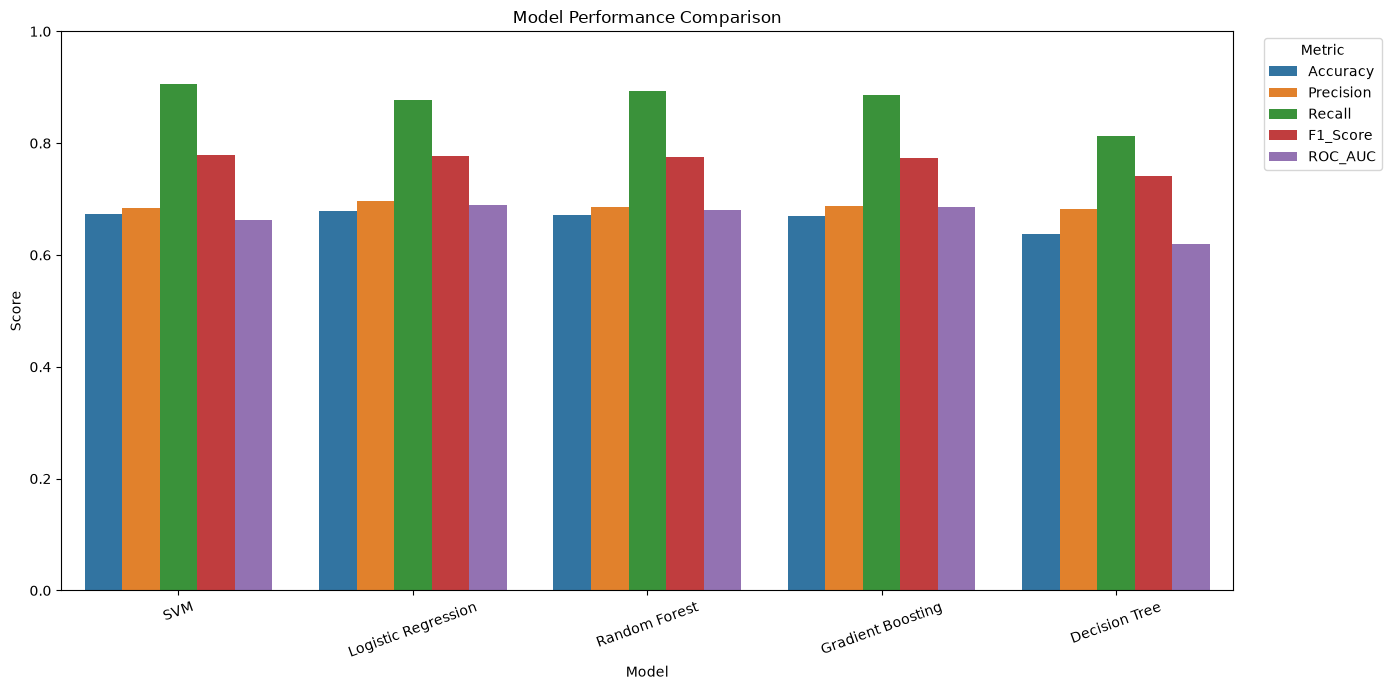

In [6]:
metrics_to_plot = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1_Score",
    "ROC_AUC"
]

comparison_long = results_df.melt(
    id_vars="Model",
    value_vars=metrics_to_plot,
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(14, 7))

sns.barplot(
    data=comparison_long,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)

plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## 7. Confusion Matrices

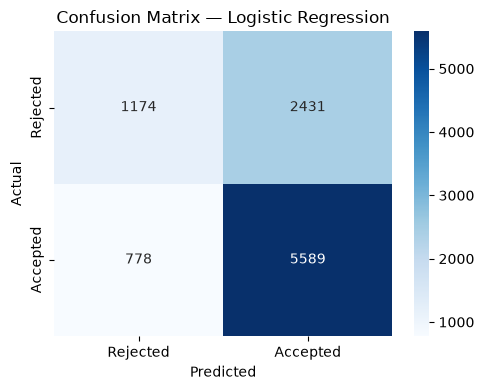

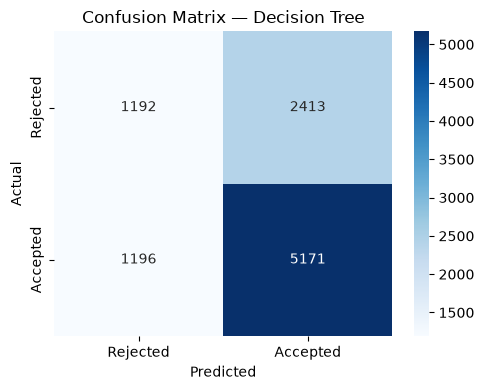

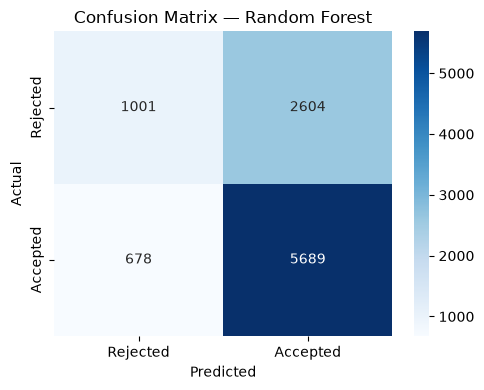

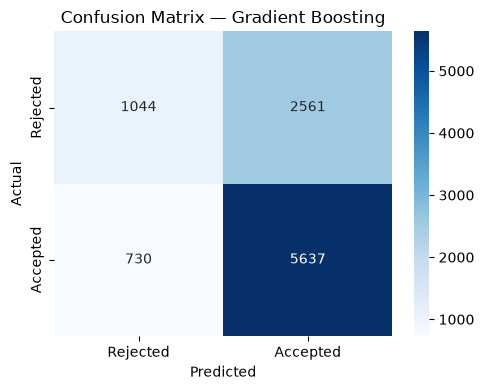

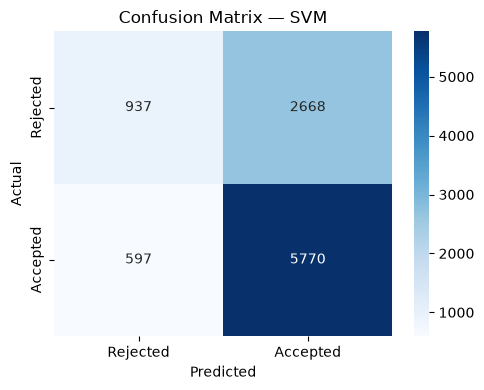

In [7]:
for name in models:

    cm = confusion_matrix(
        y_test,
        predictions[name]
    )

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Rejected", "Accepted"],
        yticklabels=["Rejected", "Accepted"]
    )

    plt.title(f"Confusion Matrix — {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.tight_layout()
    plt.show()

## 8. ROC Curves

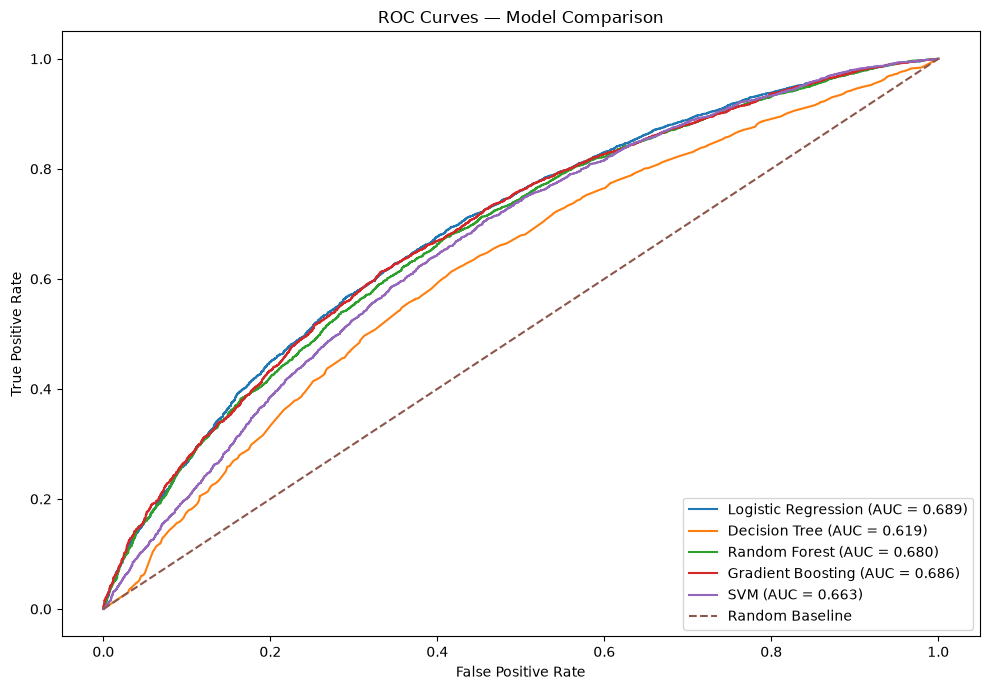

In [8]:
plt.figure(figsize=(10, 7))

for name in models:

    fpr, tpr, _ = roc_curve(
        y_test,
        probabilities[name]
    )

    auc_value = roc_auc_score(
        y_test,
        probabilities[name]
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc_value:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Baseline"
)

plt.title("ROC Curves — Model Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 9. Classification Reports

In [9]:
for name in models:

    print("=" * 75)
    print(name)
    print("=" * 75)

    print(
        classification_report(
            y_test,
            predictions[name],
            target_names=["Rejected", "Accepted"],
            zero_division=0
        )
    )

Logistic Regression
              precision    recall  f1-score   support

    Rejected       0.60      0.33      0.42      3605
    Accepted       0.70      0.88      0.78      6367

    accuracy                           0.68      9972
   macro avg       0.65      0.60      0.60      9972
weighted avg       0.66      0.68      0.65      9972

Decision Tree
              precision    recall  f1-score   support

    Rejected       0.50      0.33      0.40      3605
    Accepted       0.68      0.81      0.74      6367

    accuracy                           0.64      9972
   macro avg       0.59      0.57      0.57      9972
weighted avg       0.62      0.64      0.62      9972

Random Forest
              precision    recall  f1-score   support

    Rejected       0.60      0.28      0.38      3605
    Accepted       0.69      0.89      0.78      6367

    accuracy                           0.67      9972
   macro avg       0.64      0.59      0.58      9972
weighted avg       0.65   

## 10. Compare Models by Metric

This table provides the full numerical comparison.

No single metric is assumed to be the objective before reviewing the results.

In [10]:
display(
    results_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1_Score": "{:.4f}",
        "ROC_AUC": "{:.4f}"
    })
)

results_path = OUTPUT_DIR / "model_comparison_results.csv"
results_df.to_csv(results_path, index=False)

print("Model comparison saved to:", results_path)

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,SVM,0.6726,0.6838,0.9062,0.7795,0.6634
1,Logistic Regression,0.6782,0.6969,0.8778,0.7770,0.6894
2,Random Forest,0.6709,0.6860,0.8935,0.7761,0.6798
3,Gradient Boosting,0.6700,0.6876,0.8853,0.7740,0.6859
4,Decision Tree,0.6381,0.6818,0.8122,0.7413,0.6190


Model comparison saved to: D:\job acceptance prediction system\outputs\model_comparison_results.csv


## 11. Select the Candidate Final Model

For this binary classification project, **F1 Score** is used as the primary selection metric because it balances precision and recall.

The selection below is based on the actual test-set results rather than a preselected model.

In [11]:
best_model_name = results_df.loc[
    results_df["F1_Score"].idxmax(),
    "Model"
]

best_model = trained_models[best_model_name]

print("Candidate final model:", best_model_name)

best_row = results_df[
    results_df["Model"] == best_model_name
].iloc[0]

display(
    best_row.to_frame("Value")
)

Candidate final model: SVM


,Value
Model,SVM
Accuracy,0.672583
Precision,0.683811
Recall,0.906235
F1_Score,0.779466
ROC_AUC,0.663359


## 12. Detailed Evaluation of the Candidate Final Model

In [12]:
best_predictions = predictions[best_model_name]
best_probabilities = probabilities[best_model_name]

print(f"Candidate final model: {best_model_name}")
print()

print(
    classification_report(
        y_test,
        best_predictions,
        target_names=["Rejected", "Accepted"],
        zero_division=0
    )
)

print("Confusion Matrix:")
display(
    pd.DataFrame(
        confusion_matrix(
            y_test,
            best_predictions
        ),
        index=["Actual Rejected", "Actual Accepted"],
        columns=["Predicted Rejected", "Predicted Accepted"]
    )
)

print(
    "ROC-AUC:",
    round(
        roc_auc_score(
            y_test,
            best_probabilities
        ),
        4
    )
)

Candidate final model: SVM

              precision    recall  f1-score   support

    Rejected       0.61      0.26      0.36      3605
    Accepted       0.68      0.91      0.78      6367

    accuracy                           0.67      9972
   macro avg       0.65      0.58      0.57      9972
weighted avg       0.66      0.67      0.63      9972

Confusion Matrix:


,Predicted Rejected,Predicted Accepted
Actual Rejected,937,2668
Actual Accepted,597,5770


ROC-AUC: 0.6634


## 13. Save the Candidate Final Model

The selected model is saved as `final_model.joblib`.

This is the model that Notebook 05 can use for threshold analysis, final evaluation, and application integration.

The model is selected from the measured comparison results; it is not assumed beforehand.

In [13]:
FINAL_MODEL_PATH = MODEL_DIR / "final_model.joblib"

joblib.dump(
    best_model,
    FINAL_MODEL_PATH
)

print("Final model saved to:")
print(FINAL_MODEL_PATH)

Final model saved to:
D:\job acceptance prediction system\models\final_model.joblib


## 14. Reload Final Model and Verify

In [14]:
loaded_final_model = joblib.load(FINAL_MODEL_PATH)

reloaded_predictions = loaded_final_model.predict(X_test)

reloaded_accuracy = accuracy_score(
    y_test,
    reloaded_predictions
)

original_accuracy = accuracy_score(
    y_test,
    best_predictions
)

print("Reloaded model:", type(loaded_final_model))
print("Original accuracy:", round(original_accuracy, 6))
print("Reloaded accuracy:", round(reloaded_accuracy, 6))

if not np.isclose(
    original_accuracy,
    reloaded_accuracy
):
    raise ValueError(
        "Reloaded model predictions do not match the saved model."
    )

print("Saved model verification passed.")

Reloaded model: <class 'sklearn.svm._classes.SVC'>
Original accuracy: 0.672583
Reloaded accuracy: 0.672583
Saved model verification passed.


## 15. Final Notebook 04 Validation

In [15]:
best_metrics = results_df[
    results_df["Model"] == best_model_name
].iloc[0]

print("NOTEBOOK 04 VALIDATION")
print("=" * 70)

print(f"Training rows: {X_train.shape[0]:,}")
print(f"Testing rows: {X_test.shape[0]:,}")
print(f"Input features: {X_train.shape[1]:,}")
print(f"Models trained: {len(models)}")
print(f"Candidate final model: {best_model_name}")

print("\nCandidate final-model metrics:")
print(f"Accuracy:  {best_metrics['Accuracy']:.4f}")
print(f"Precision: {best_metrics['Precision']:.4f}")
print(f"Recall:    {best_metrics['Recall']:.4f}")
print(f"F1 Score:  {best_metrics['F1_Score']:.4f}")
print(f"ROC-AUC:   {best_metrics['ROC_AUC']:.4f}")

print("\nSaved files:")
print("-", results_path)
print("-", FINAL_MODEL_PATH)

print("\nNotebook 04 completed successfully.")

NOTEBOOK 04 VALIDATION
Training rows: 39,888
Testing rows: 9,972
Input features: 102
Models trained: 5
Candidate final model: SVM

Candidate final-model metrics:
Accuracy:  0.6726
Precision: 0.6838
Recall:    0.9062
F1 Score:  0.7795
ROC-AUC:   0.6634

Saved files:
- D:\job acceptance prediction system\outputs\model_comparison_results.csv
- D:\job acceptance prediction system\models\final_model.joblib

Notebook 04 completed successfully.
